# Notebook 01 — Linear Regression & Logistic Regression
  **Linear Regression** → Predict WQI (numerical value)
  **Logistic Regression** → Predict Water Quality Classification (category)

  ### Why these algorithms?
  - Simplest models — great for understanding the **baseline**
  - Linear Regression assumes a straight-line relationship between features and WQI
  - Logistic Regression extends that idea to predict probabilities across classes
  - If complex models barely beat these, the problem is mostly linear



In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
  r2_score, mean_squared_error, mean_absolute_error,
  accuracy_score, f1_score, classification_report, confusion_matrix
)

In [2]:
with open('processed_data.pkl', 'rb') as f:
  data = pickle.load(f)

X_train      = data['X_train']
X_test       = data['X_test']
y_reg_train  = data['y_reg_train']
y_reg_test   = data['y_reg_test']
y_clf_train  = data['y_clf_train']
y_clf_test   = data['y_clf_test']
le           = data['label_encoder']
feature_names = data['feature_names']

print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)
print("Classes   :", list(le.classes_))

Train size: (15223, 30)
Test  size: (3806, 30)
Classes   : ['Excellent', 'Good', 'Poor', 'Unsuitable for Drinking', 'Very Poor yet Drinkable']


## Part 1 — Linear Regression (Predict WQI)
  Linear Regression fits a line (or hyperplane) through the data:

  **WQI = w1×pH + w2×EC + w3×HCO3 + ... + bias**

  Each weight `w` tells us how much that feature contributes to WQI.
  Metric used: **R² score** (1.0 = perfect, 0 = no better than predicting the mean)

In [3]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test  = lr_model.predict(X_test)

r2_train = r2_score(y_reg_train, y_pred_train)
r2_test  = r2_score(y_reg_test,  y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_reg_test, y_pred_test))
mae      = mean_absolute_error(y_reg_test, y_pred_test)

print("=== Linear Regression — WQI ===")
print(f"R² Train : {r2_train:.4f}")
print(f"R² Test  : {r2_test:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")


=== Linear Regression — WQI ===
R² Train : 1.0000
R² Test  : 1.0000
RMSE     : 0.00
MAE      : 0.00


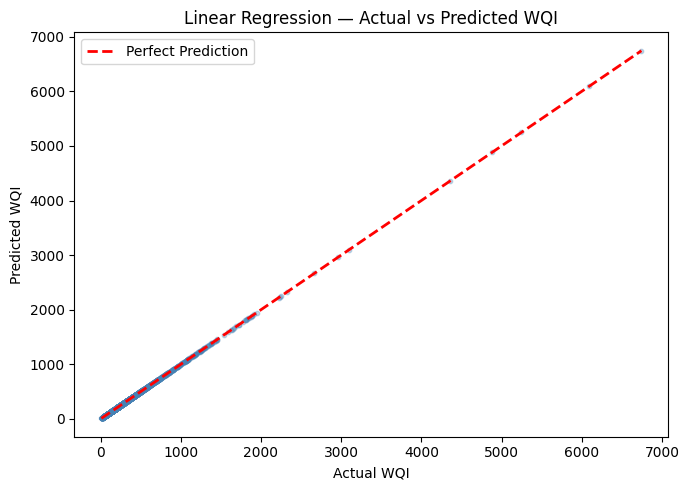

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test, y_pred_test, alpha=0.3, color='steelblue', s=10)
plt.plot([y_reg_test.min(), y_reg_test.max()],
       [y_reg_test.min(), y_reg_test.max()],
       'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual WQI')
plt.ylabel('Predicted WQI')
plt.title('Linear Regression — Actual vs Predicted WQI')
plt.legend()
plt.tight_layout()
plt.show()

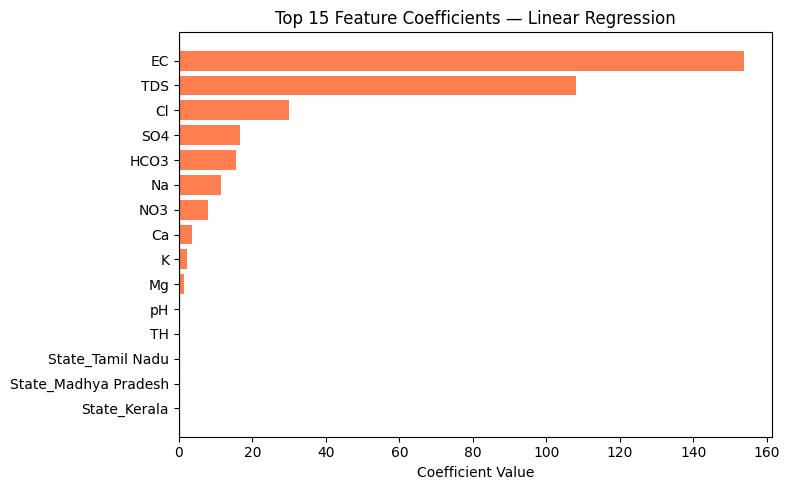

In [5]:
coef_df = (
  __import__('pandas').DataFrame({'Feature': feature_names, 'Coefficient': lr_model.coef_})
  .reindex(columns=['Feature', 'Coefficient'])
  .sort_values('Coefficient', key=abs, ascending=False)
  .head(15)
)

plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='coral')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients — Linear Regression')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Part 2 — Logistic Regression (Predict Water Quality Classification)
  Logistic Regression applies a **softmax** function to output probabilities
  for each class, then picks the class with the highest probability.

  It is NOT just for binary — `multi_class='multinomial'` handles 5 classes here.
  Metrics: **Accuracy** and **F1 Score (weighted)** — F1 accounts for class imbalance.

In [14]:
#Train Logistic Regression
log_model = LogisticRegression(
  solver='lbfgs',
  max_iter=1000,
  random_state=42
)
log_model.fit(X_train, y_clf_train)

y_clf_pred_train = log_model.predict(X_train)
y_clf_pred_test  = log_model.predict(X_test)

acc_train = accuracy_score(y_clf_train, y_clf_pred_train)
acc_test  = accuracy_score(y_clf_test,  y_clf_pred_test)
f1_test   = f1_score(y_clf_test, y_clf_pred_test, average='weighted')
f1_train   = f1_score(y_clf_train, y_clf_pred_train, average='weighted')

print("=== Logistic Regression — Classification ===")
print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")
print(f"F1 Score Test  : {f1_test:.4f}")
print(f"F1 Score Train  : {f1_train:.4f}")



=== Logistic Regression — Classification ===
Accuracy Train : 0.9631
Accuracy Test  : 0.9611
F1 Score Test  : 0.9609
F1 Score Train  : 0.9628


In [8]:
#Classification Report
print("=== Detailed Classification Report ===")
print(classification_report(
  y_clf_test,
  y_clf_pred_test,
  target_names=le.classes_
))


=== Detailed Classification Report ===
                         precision    recall  f1-score   support

              Excellent       0.85      0.89      0.87       136
                   Good       0.90      0.82      0.86       317
                   Poor       0.95      0.97      0.96      1066
Unsuitable for Drinking       0.99      0.99      0.99      1370
Very Poor yet Drinkable       0.96      0.97      0.97       917

               accuracy                           0.96      3806
              macro avg       0.93      0.93      0.93      3806
           weighted avg       0.96      0.96      0.96      3806



 Precision, Recall, F1 — What they mean

  Precision = Of all samples predicted as class X, how many were actually X?
  Recall    = Of all actual class X samples, how many did the model find?
  F1        = Harmonic mean of Precision & Recall (balance between the two)

. Precision
Definition: Out of all the instances the model predicted as positive, how many were actually positive?
Formula:
Precision= 
TP+FP
TP
​	
 
Where:
TP (True Positives): Correctly predicted positive cases.
FP (False Positives): Incorrectly predicted positive cases.
Example:
Suppose a model predicts 100 emails as spam:
80 are actually spam (TP = 80)
20 are not spam (FP = 20)
Precision:
80+20
80
​	
 =0.80=80%
Interpretation:
High precision means few false alarms.
Important when false positives are costly.
Example applications:
Email spam detection
Fraud detection
Predicting a rare disease where unnecessary treatment should be minimized
2. Recall (Sensitivity or True Positive Rate)
Definition: Out of all the actual positive cases, how many did the model correctly identify?
Formula:
Recall= 
TP+FN
TP
​	
 
Where:
FN (False Negatives): Positive cases that the model missed.
Example:
There are actually 120 spam emails:
Model correctly identifies 80 (TP = 80)
Misses 40 (FN = 40)
Recall:
80+40
80
​	
 =0.667=66.7%
Interpretation:
High recall means few missed positive cases.
Important when missing a positive is expensive.
Example applications:
Cancer diagnosis
COVID detection
Fraud detection
3. F1 Score
Definition: The harmonic mean of Precision and Recall.
Formula:
F1= 
Precision+Recall
2×(Precision×Recall)
​	
 
Example:
Precision = 0.80
Recall = 0.667
F1:
F1= 
0.8+0.667
2(0.8)(0.667)
​	
 =0.727
So,
F1 Score = 72.7%
Interpretation:
High only when both precision and recall are high.
Useful when you need a balance between false positives and false negatives.

Real-life Example (Disease Detection)
Suppose 1,000 people are tested.
100 actually have the disease.
Model predicts 90 people have the disease.
Of those 90:
80 truly have it (TP = 80)
10 do not (FP = 10)
The model misses 20 sick people (FN = 20).
Precision
80+10
80
​	
 =88.9%
Meaning:
When the model predicts someone is sick, it is correct 88.9% of the time.
Recall
80+20
80
Meaning:
The model detects 80% of all sick patients.
F1 Score
0.889+0.80
2(0.889)(0.80)
​	
 =84.2%

 

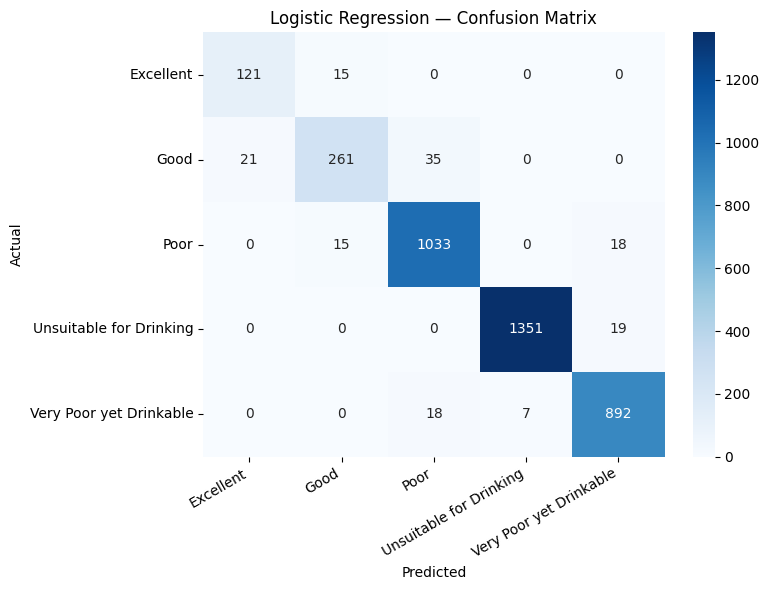

In [9]:
#Confusion Matrix
cm = confusion_matrix(y_clf_test, y_clf_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=le.classes_,
          yticklabels=le.classes_)
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


 ## Results Summary

  | Model | Task | Train Score | Test Score |
  |-------|------|-------------|------------|
  | Linear Regression | WQI (R²) | 1.0 | 1.0 |
  | Logistic Regression | Classification (Accuracy) | 0.9631 | 0.9611 |
  | Logistic Regression | Classification (F1) | 0.9628 | 0.9609 |


  ### Key Observations:
  - If R² is low → WQI has non-linear relationships that linear models can't capture
  - If Accuracy is low → classes may overlap in feature space
  - Next: Decision Tree will capture non-linearity better



In [19]:
#Save Results for Comparison
import pandas as pd

summary = pd.DataFrame([
  {
      'Model': 'Linear Regression',
      'Task': 'WQI (R²)',
      'Train Score': round(r2_train, 4),
      'Test Score':  round(r2_test,  4),
      'Extra': f"RMSE = {rmse:.2f}"
  },
  {
      'Model': 'Logistic Regression',
      'Task': 'Classification (Accuracy)',
      'Train Score': round(acc_train, 4),
      'Test Score':  round(acc_test,  4),
      'Extra': '—'
  },
  {
      'Model': 'Logistic Regression',
      'Task': 'Classification (F1)',
      'Train Score': '—',
      'Test Score':  round(f1_test, 4),
      'Extra': '—'
  }
])

In [21]:
#display(summary)

if r2_test > 0.99:
  reg_obs = 'Perfect fit — WQI is derived from features'
else:
  reg_obs = 'Non-linear relationships exist'

if acc_test > 0.90:
  clf_obs = 'Strong linear separability'
else:
  clf_obs = 'Classes overlap in feature space'

gap = abs(acc_train - acc_test)
if gap < 0.02:
  gap_obs = 'Minimal overfitting'
else:
  gap_obs = 'Overfitting present'

print("=== Key Observations ===")
print("Linear Regression R2 Test :", round(r2_test, 4), "->", reg_obs)
print("Logistic Accuracy Test    :", round(acc_test, 4), "->", clf_obs)
print("Train vs Test Acc gap     :", round(gap, 4), "->", gap_obs)
print("Next: Decision Tree will capture non-linearity better")


=== Key Observations ===
Linear Regression R2 Test : 1.0 -> Perfect fit — WQI is derived from features
Logistic Accuracy Test    : 0.9611 -> Strong linear separability
Train vs Test Acc gap     : 0.002 -> Minimal overfitting
Next: Decision Tree will capture non-linearity better


In [18]:
results = {
  'Linear Regression': {
      'task': 'Regression',
      'r2_train': r2_train,
      'r2_test': r2_test,
      'rmse': rmse
  },
  'Logistic Regression': {
      'task': 'Classification',
      'acc_train': acc_train,
      'acc_test': acc_test,
      'f1_test': f1_test
  }
}

with open('results_01_linear_logistic.pkl', 'wb') as f:
  pickle.dump(results, f)

print("Results saved. Move on to 02_Decision_Tree.ipynb")

Results saved. Move on to 02_Decision_Tree.ipynb
